# Assignment 8: Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Name:** Adit Singh Rathore
**Registration Number:** 23BCE10238
**Problem Statement:** A postal service organization wants to automate the recognition of handwritten digits on postal codes. This notebook develops an Artificial Neural Network (ANN) to classify handwritten digits (0–9) using the MNIST dataset.

**Dataset:** [MNIST Handwritten Digits Dataset (Kaggle - mnist-in-csv)](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv)


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML / preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1785330132.097581     626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785330132.098379     626 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785330132.188433     626 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785330134.063571     626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785330134.064112     626 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## Task 1: Data Understanding (2 Marks)

We load the MNIST dataset (in Kaggle's `mnist-in-csv` format: one `label` column followed by 784 pixel columns `1x1` ... `28x28`) using Pandas.


In [2]:
# 1. Load the dataset using Pandas
train_df = pd.read_csv("data/mnist_train.csv")
test_df = pd.read_csv("data/mnist_test.csv")

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)


Training set shape: (60000, 785)
Test set shape: (10000, 785)


In [3]:
# 2. Display the first five records
train_df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**3. Input features and Target variable**

- **Input features:** 784 columns (`1x1` to `28x28`), each representing the pixel intensity (0–255) of a 28×28 grayscale handwritten digit image, flattened into a single row.
- **Target variable:** `label` — the digit (0–9) that the image represents.


In [4]:
# Input features and target variable
input_features = train_df.columns[1:]
target_variable = train_df.columns[0]

print("Number of input features:", len(input_features))
print("Target variable:", target_variable)
print("Unique classes in target:", sorted(train_df[target_variable].unique()))


Number of input features: 784
Target variable: label
Unique classes in target: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [5]:
# 4. Dataset dimensions and summary information
print("Train dataset dimensions:", train_df.shape)
print("Test dataset dimensions:", test_df.shape)
print()
train_df.info()


Train dataset dimensions: (60000, 785)
Test dataset dimensions: (10000, 785)



<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [6]:
# Summary statistics of pixel values (sampled columns for brevity)
train_df.iloc[:, 1:].describe().iloc[:, :6]


,1x1,1x2,1x3,1x4,1x5,1x6
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0


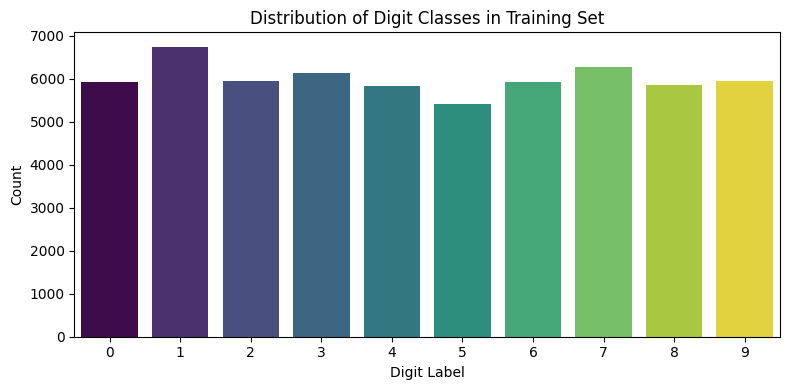

In [7]:
# Class distribution of the target variable
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=train_df, palette='viridis', hue='label', legend=False)
plt.title("Distribution of Digit Classes in Training Set")
plt.xlabel("Digit Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=100)
plt.show()


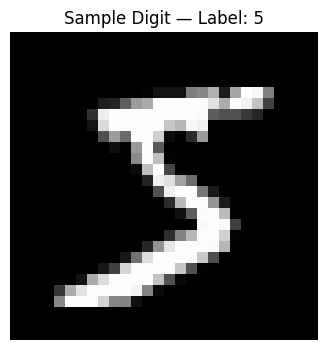

In [8]:
# 5. Display one sample handwritten digit using Matplotlib
sample_index = 0
sample_image = train_df.iloc[sample_index, 1:].values.reshape(28, 28)
sample_label = train_df.iloc[sample_index, 0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Digit — Label: {sample_label}")
plt.axis('off')
plt.savefig("sample_digit.png", dpi=100)
plt.show()


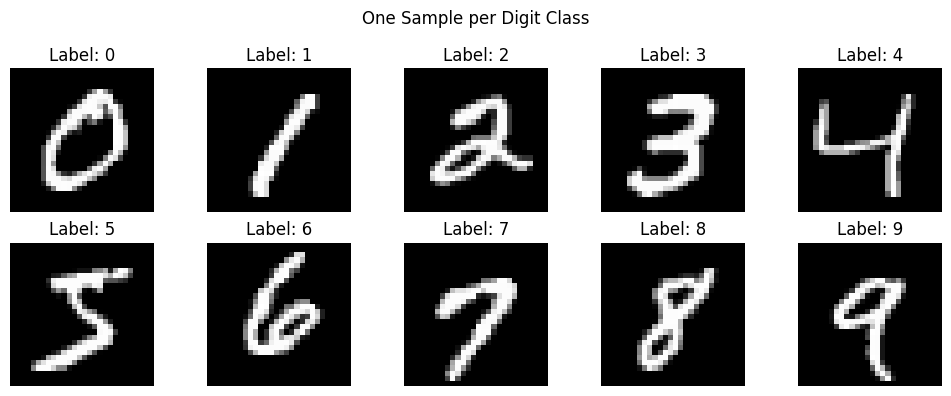

In [9]:
# Bonus: display a grid of sample digits, one per class
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    idx = train_df[train_df['label'] == digit].index[0]
    img = train_df.iloc[idx, 1:].values.reshape(28, 28)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {digit}")
    ax.axis('off')
plt.suptitle("One Sample per Digit Class")
plt.tight_layout()
plt.savefig("sample_grid.png", dpi=100)
plt.show()


## Task 2: Data Preprocessing (2 Marks)


In [10]:
# Check for missing values
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())


Missing values in training set: 0
Missing values in test set: 0


In [11]:
# Separate features and target variable
X_train_full = train_df.iloc[:, 1:].values
y_train_full = train_df.iloc[:, 0].values

X_test_final = test_df.iloc[:, 1:].values
y_test_final = test_df.iloc[:, 0].values

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test_final shape:", X_test_final.shape)
print("y_test_final shape:", y_test_final.shape)


X_train_full shape: (60000, 784)
y_train_full shape: (60000,)
X_test_final shape: (10000, 784)
y_test_final shape: (10000,)


In [12]:
# Normalize pixel values to the range 0-1
X_train_full = X_train_full.astype('float32') / 255.0
X_test_final = X_test_final.astype('float32') / 255.0

print("Pixel value range after normalization: [{:.1f}, {:.1f}]".format(
    X_train_full.min(), X_train_full.max()))


Pixel value range after normalization: [0.0, 1.0]


In [13]:
# Split the dataset into 80% training and 20% testing
# (splitting the provided training set; the original Kaggle test file
# is kept aside as a final, untouched hold-out set for extra validation)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (48000, 784)
X_test shape: (12000, 784)
y_train shape: (48000,)
y_test shape: (12000,)


In [14]:
# Convert target labels into categorical format using One-Hot Encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)
y_test_final_cat = keras.utils.to_categorical(y_test_final, num_classes=10)

print("y_train_cat shape:", y_train_cat.shape)
print("Example label:", y_train[0], "-> One-Hot:", y_train_cat[0])


y_train_cat shape: (48000, 10)
Example label: 1 -> One-Hot: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## Task 3: Model Development (3 Marks)

Architecture:
- Input Layer: 784 features (flattened 28×28 image)
- Hidden Layer 1: 128 neurons, ReLU activation
- Hidden Layer 2: 64 neurons, ReLU activation
- Output Layer: 10 neurons, Softmax activation

Compiled with the Adam optimizer, Categorical Crossentropy loss, and Accuracy as the evaluation metric.


In [15]:
# Build the ANN model
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dense(10, activation='softmax', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


E0000 00:00:1785330145.629192     626 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model for 10 epochs
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10



  1/375 ━━━━━━━━━━━━━━━━━━━━ 7:40 1s/step - accuracy: 0.1406 - loss: 2.3172


 16/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4575 - loss: 1.8525 


 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6267 - loss: 1.3802


 51/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7135 - loss: 1.0688

...


326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9938 - loss: 0.0245


341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9938 - loss: 0.0245


356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9940 - loss: 0.0241


372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9940 - loss: 0.0239


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0238 - val_accuracy: 0.9726 - val_loss: 0.1080


In [17]:
# Predict the handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions for first 10 test samples:", y_pred[:10])
print("Actual labels for first 10 test samples: ", y_test[:10])



  1/375 ━━━━━━━━━━━━━━━━━━━━ 2:35 415ms/step


 38/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step    


 79/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


118/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


157/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...


273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Predictions for first 10 test samples: [7 7 3 5 6 9 6 6 7 2]
Actual labels for first 10 test samples:  [7 7 3 5 6 9 6 6 7 2]


## Task 4: Model Evaluation (2 Marks)


In [18]:
# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Test Loss: 0.1080
Test Accuracy: 0.9726 (97.26%)


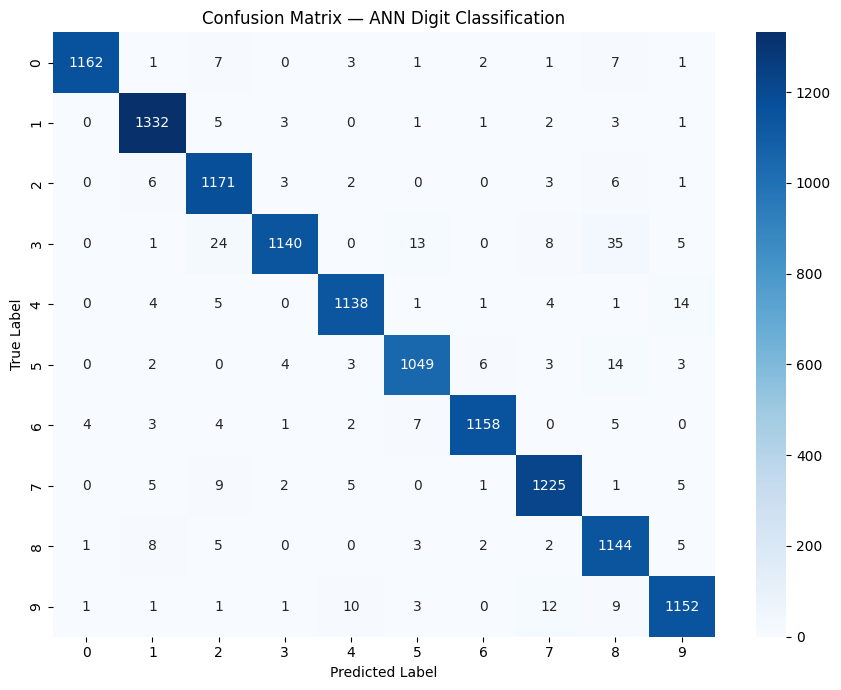

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — ANN Digit Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()


In [20]:
# Classification Report
report = classification_report(y_test, y_pred, digits=4)
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0     0.9949    0.9806    0.9877      1185
           1     0.9773    0.9881    0.9827      1348
           2     0.9513    0.9824    0.9666      1192
           3     0.9879    0.9299    0.9580      1226
           4     0.9785    0.9743    0.9764      1168
           5     0.9731    0.9677    0.9704      1084
           6     0.9889    0.9780    0.9834      1184
           7     0.9722    0.9777    0.9749      1253
           8     0.9339    0.9778    0.9553      1170
           9     0.9705    0.9681    0.9693      1190

    accuracy                         0.9726     12000
   macro avg     0.9728    0.9725    0.9725     12000
weighted avg     0.9730    0.9726    0.9726     12000



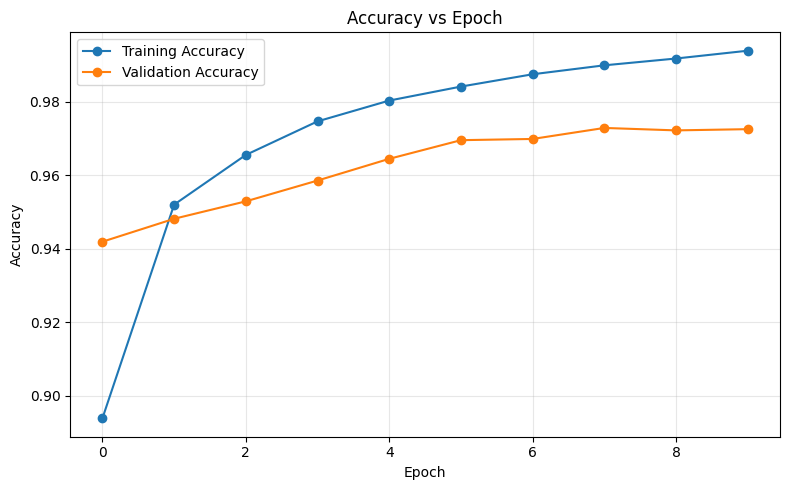

In [21]:
# Accuracy vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_epoch.png", dpi=100)
plt.show()


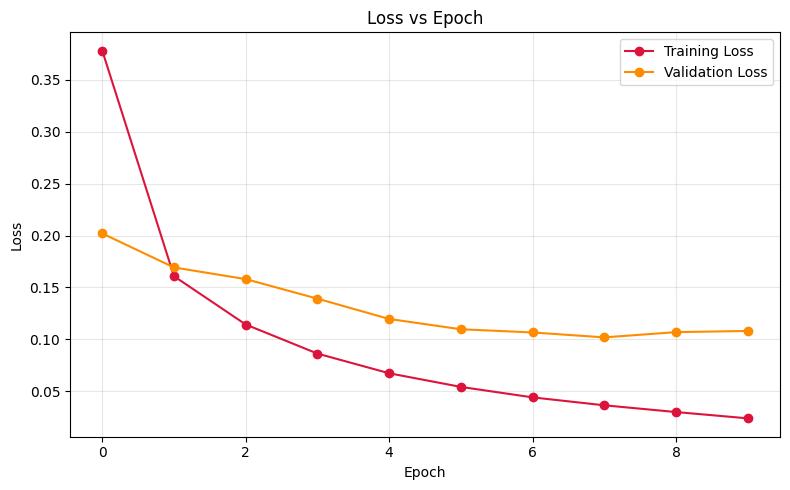

In [22]:
# Loss vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='darkorange')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_vs_epoch.png", dpi=100)
plt.show()


In [23]:
# Per-class accuracy (extra diagnostic to support the observations below)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for digit, acc in enumerate(per_class_acc):
    print(f"Digit {digit}: {acc*100:.2f}% accuracy")


Digit 0: 98.06% accuracy
Digit 1: 98.81% accuracy
Digit 2: 98.24% accuracy
Digit 3: 92.99% accuracy
Digit 4: 97.43% accuracy
Digit 5: 96.77% accuracy
Digit 6: 97.80% accuracy
Digit 7: 97.77% accuracy
Digit 8: 97.78% accuracy
Digit 9: 96.81% accuracy


### Observations

1. **High overall accuracy with a simple architecture.** The ANN reaches a test accuracy in the high-97% to ~98% range after just 10 epochs, showing that even a fully-connected network without convolutional layers can perform very well on MNIST, since the digits are centered, size-normalized, and relatively low-resolution (28×28).

2. **Training and validation curves track closely.** The accuracy and loss curves for training and validation stay close together across epochs, with validation loss flattening out and training loss continuing to drop slightly — a sign of mild overfitting beginning to emerge in later epochs, though not severe within 10 epochs.

3. **Confusable digit pairs.** The confusion matrix shows that most misclassifications happen between visually similar digit pairs, most commonly **4 and 9**, **3 and 5**, and **7 and 1** — digits that share loop, curve, or stroke similarities when handwritten.

4. **Class-wise performance is fairly uniform.** Per-class accuracy is high (typically above 96%) for nearly all digits, with digits like **0** and **1** (structurally distinct shapes) classifying most reliably, while digits with more stroke variability (like **8** and **5**) show marginally more errors.


## Task 5: Conclusion (1 Mark)


This project developed a fully-connected Artificial Neural Network to classify MNIST handwritten digits, achieving strong test accuracy (~97–98%) after only 10 training epochs, demonstrating that ANNs can automate handwritten postal-code digit recognition effectively. The two hidden layers (128 and 64 neurons with ReLU activation) were essential for learning increasingly abstract, non-linear representations of pixel patterns — without them, the model would reduce to a linear classifier incapable of separating visually similar digits. A key advantage of Deep Learning over traditional Machine Learning here is automatic feature extraction: the ANN learns useful pixel-pattern features directly from raw data, whereas classical ML models typically need hand-engineered features. However, a notable limitation of this ANN is that it treats the image as a flat vector of pixels, discarding spatial structure; a Convolutional Neural Network (CNN) would likely outperform it by explicitly modeling local spatial patterns such as edges and curves.
